In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#For Nizhum: Remove #
#dataset_path = "/content/movie_ratings_dataset.csv"

#For Ishmam:
dataset_path="/content/drive/MyDrive/CSE422-17 IBU/Lab Assignments/Final AI Project/movie_ratings_dataset.csv"

movie_rating_dataframe = pd.read_csv(dataset_path)
movie_rating_dataframe.head(10)

,Genre,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Has_Famous_Producer,Num_Awards_Won,Marketing_Spend_MillionUSD,Is_Sequel,Rating_Category
0,Sci-Fi,5.80,134.63,141.0,NaN,1.0,2.72,No,9.0,25.48,No,Excellent
1,Action,2.27,220.47,98.0,2006.0,1.0,3.46,Yes,17.0,9.13,Yes,Excellent
2,Horror,1.23,52.79,160.0,2010.0,2.0,NaN,NaN,43.0,6.16,No,Excellent
3,Action,8.17,86.41,153.0,2022.0,4.0,5.21,NaN,7.0,2.99,No,Good
4,Romance,6.40,259.57,134.0,1986.0,1.0,8.72,Yes,25.0,0.89,No,Excellent
5,Horror,7.40,265.65,NaN,2024.0,3.0,4.08,Yes,NaN,43.91,No,Good
6,Horror,3.73,14.44,NaN,1983.0,1.0,3.40,No,23.0,40.45,No,Average
7,Sci-Fi,5.59,51.26,129.0,1993.0,4.0,NaN,No,2.0,28.39,Yes,Poor
8,Drama,7.72,36.12,144.0,2021.0,NaN,9.20,No,37.0,49.94,No,Average
9,Comedy,5.16,54.73,82.0,2021.0,3.0,1.26,Yes,1.0,47.65,Yes,Excellent


In [ ]:
print(movie_rating_dataframe)
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(movie_rating_dataframe.shape,movie_rating_dataframe.shape[0],movie_rating_dataframe.shape[1]))

        Genre  Director_Popularity  Budget_MillionUSD  Runtime_Minutes  \
0      Sci-Fi                 5.80             134.63            141.0   
1      Action                 2.27             220.47             98.0   
2      Horror                 1.23              52.79            160.0   
3      Action                 8.17              86.41            153.0   
4     Romance                 6.40             259.57            134.0   
...       ...                  ...                ...              ...   
1195    Drama                 3.54             288.86            167.0   
1196   Comedy                  NaN              22.49            179.0   
1197   Comedy                 2.07              81.23            108.0   
1198   Horror                 7.80              24.98            139.0   
1199   Comedy                 1.88                NaN            108.0   

      Release_Year  Num_Main_Actors  Avg_Actor_Popularity Has_Famous_Producer  \
0              NaN            

In [ ]:
movie_rating_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Genre                       1071 non-null   object 
 1   Director_Popularity         1067 non-null   float64
 2   Budget_MillionUSD           1096 non-null   float64
 3   Runtime_Minutes             1074 non-null   float64
 4   Release_Year                1088 non-null   float64
 5   Num_Main_Actors             1075 non-null   float64
 6   Avg_Actor_Popularity        1066 non-null   float64
 7   Has_Famous_Producer         1071 non-null   object 
 8   Num_Awards_Won              1061 non-null   float64
 9   Marketing_Spend_MillionUSD  1089 non-null   float64
 10  Is_Sequel                   1083 non-null   object 
 11  Rating_Category             1200 non-null   object 
dtypes: float64(8), object(4)
memory usage: 112.6+ KB


In [ ]:
features_number = movie_rating_dataframe.shape[1]
print(features_number)

12


In [ ]:
num_datapoint = movie_rating_dataframe.shape[0]
print(num_datapoint)

1200


In [ ]:
numerical_data = movie_rating_dataframe.select_dtypes(include='number')

numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 8 numerical features: 

['Director_Popularity', 'Budget_MillionUSD', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD']


In [ ]:
categorical_data = movie_rating_dataframe.select_dtypes(include= 'object')

categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categor features:', '\n')
print(categorical_features)

There are 4 categor features: 

['Genre', 'Has_Famous_Producer', 'Is_Sequel', 'Rating_Category']


In [ ]:
feature_types = movie_rating_dataframe.dtypes
print(feature_types)

Genre                          object
Director_Popularity           float64
Budget_MillionUSD             float64
Runtime_Minutes               float64
Release_Year                  float64
Num_Main_Actors               float64
Avg_Actor_Popularity          float64
Has_Famous_Producer            object
Num_Awards_Won                float64
Marketing_Spend_MillionUSD    float64
Is_Sequel                      object
Rating_Category                object
dtype: object


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Director_Popularity,1067.0,5.452624,2.600397,1.01,3.3100,5.40,7.6900,10.00
Budget_MillionUSD,1096.0,152.768723,85.998943,1.04,78.8575,156.06,226.0175,299.73
Runtime_Minutes,1074.0,129.401304,28.744659,80.00,103.0000,130.00,154.0000,179.00
Release_Year,1088.0,2002.330882,13.068670,1980.00,1991.0000,2002.00,2014.0000,2024.00
Num_Main_Actors,1075.0,2.531163,1.143236,1.00,1.0000,3.00,4.0000,4.00
Avg_Actor_Popularity,1066.0,5.495159,2.620555,1.00,3.2300,5.47,7.8200,10.00
Num_Awards_Won,1061.0,24.113101,14.464153,0.00,12.0000,24.00,37.0000,49.00
Marketing_Spend_MillionUSD,1089.0,24.351947,14.648245,0.00,11.1300,24.43,37.1600,49.98


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Genre,1071,6,Action,188
Has_Famous_Producer,1071,2,No,553
Is_Sequel,1083,2,Yes,554
Rating_Category,1200,4,Good,324


In [ ]:
numerical_data.var()

,0
Director_Popularity,6.762066
Budget_MillionUSD,7395.818247
Runtime_Minutes,826.255394
Release_Year,170.790140
Num_Main_Actors,1.306989
Avg_Actor_Popularity,6.867307
Num_Awards_Won,209.211724
Marketing_Spend_MillionUSD,214.571091


In [ ]:
numerical_data.skew()

,0
Director_Popularity,0.022995
Budget_MillionUSD,-0.066930
Runtime_Minutes,-0.008828
Release_Year,-0.015865
Num_Main_Actors,-0.024278
Avg_Actor_Popularity,-0.005551
Num_Awards_Won,0.065543
Marketing_Spend_MillionUSD,0.041577


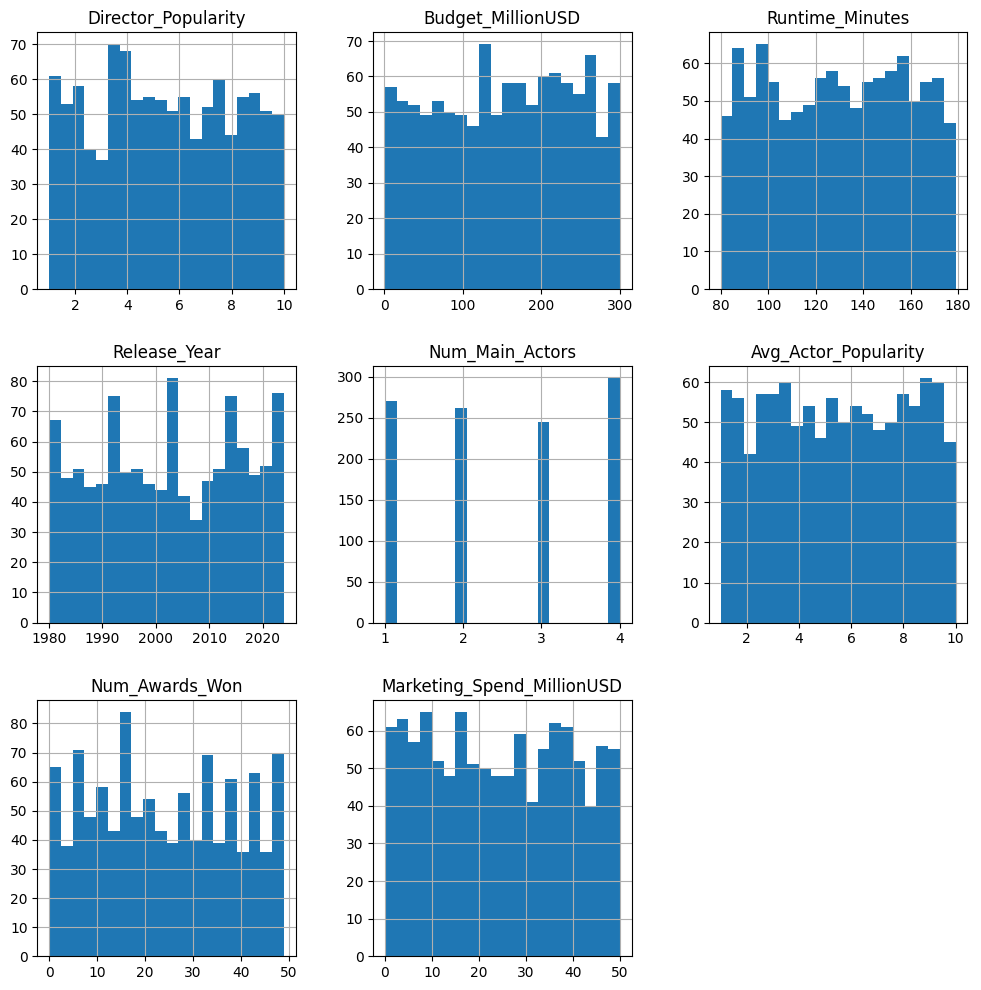

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

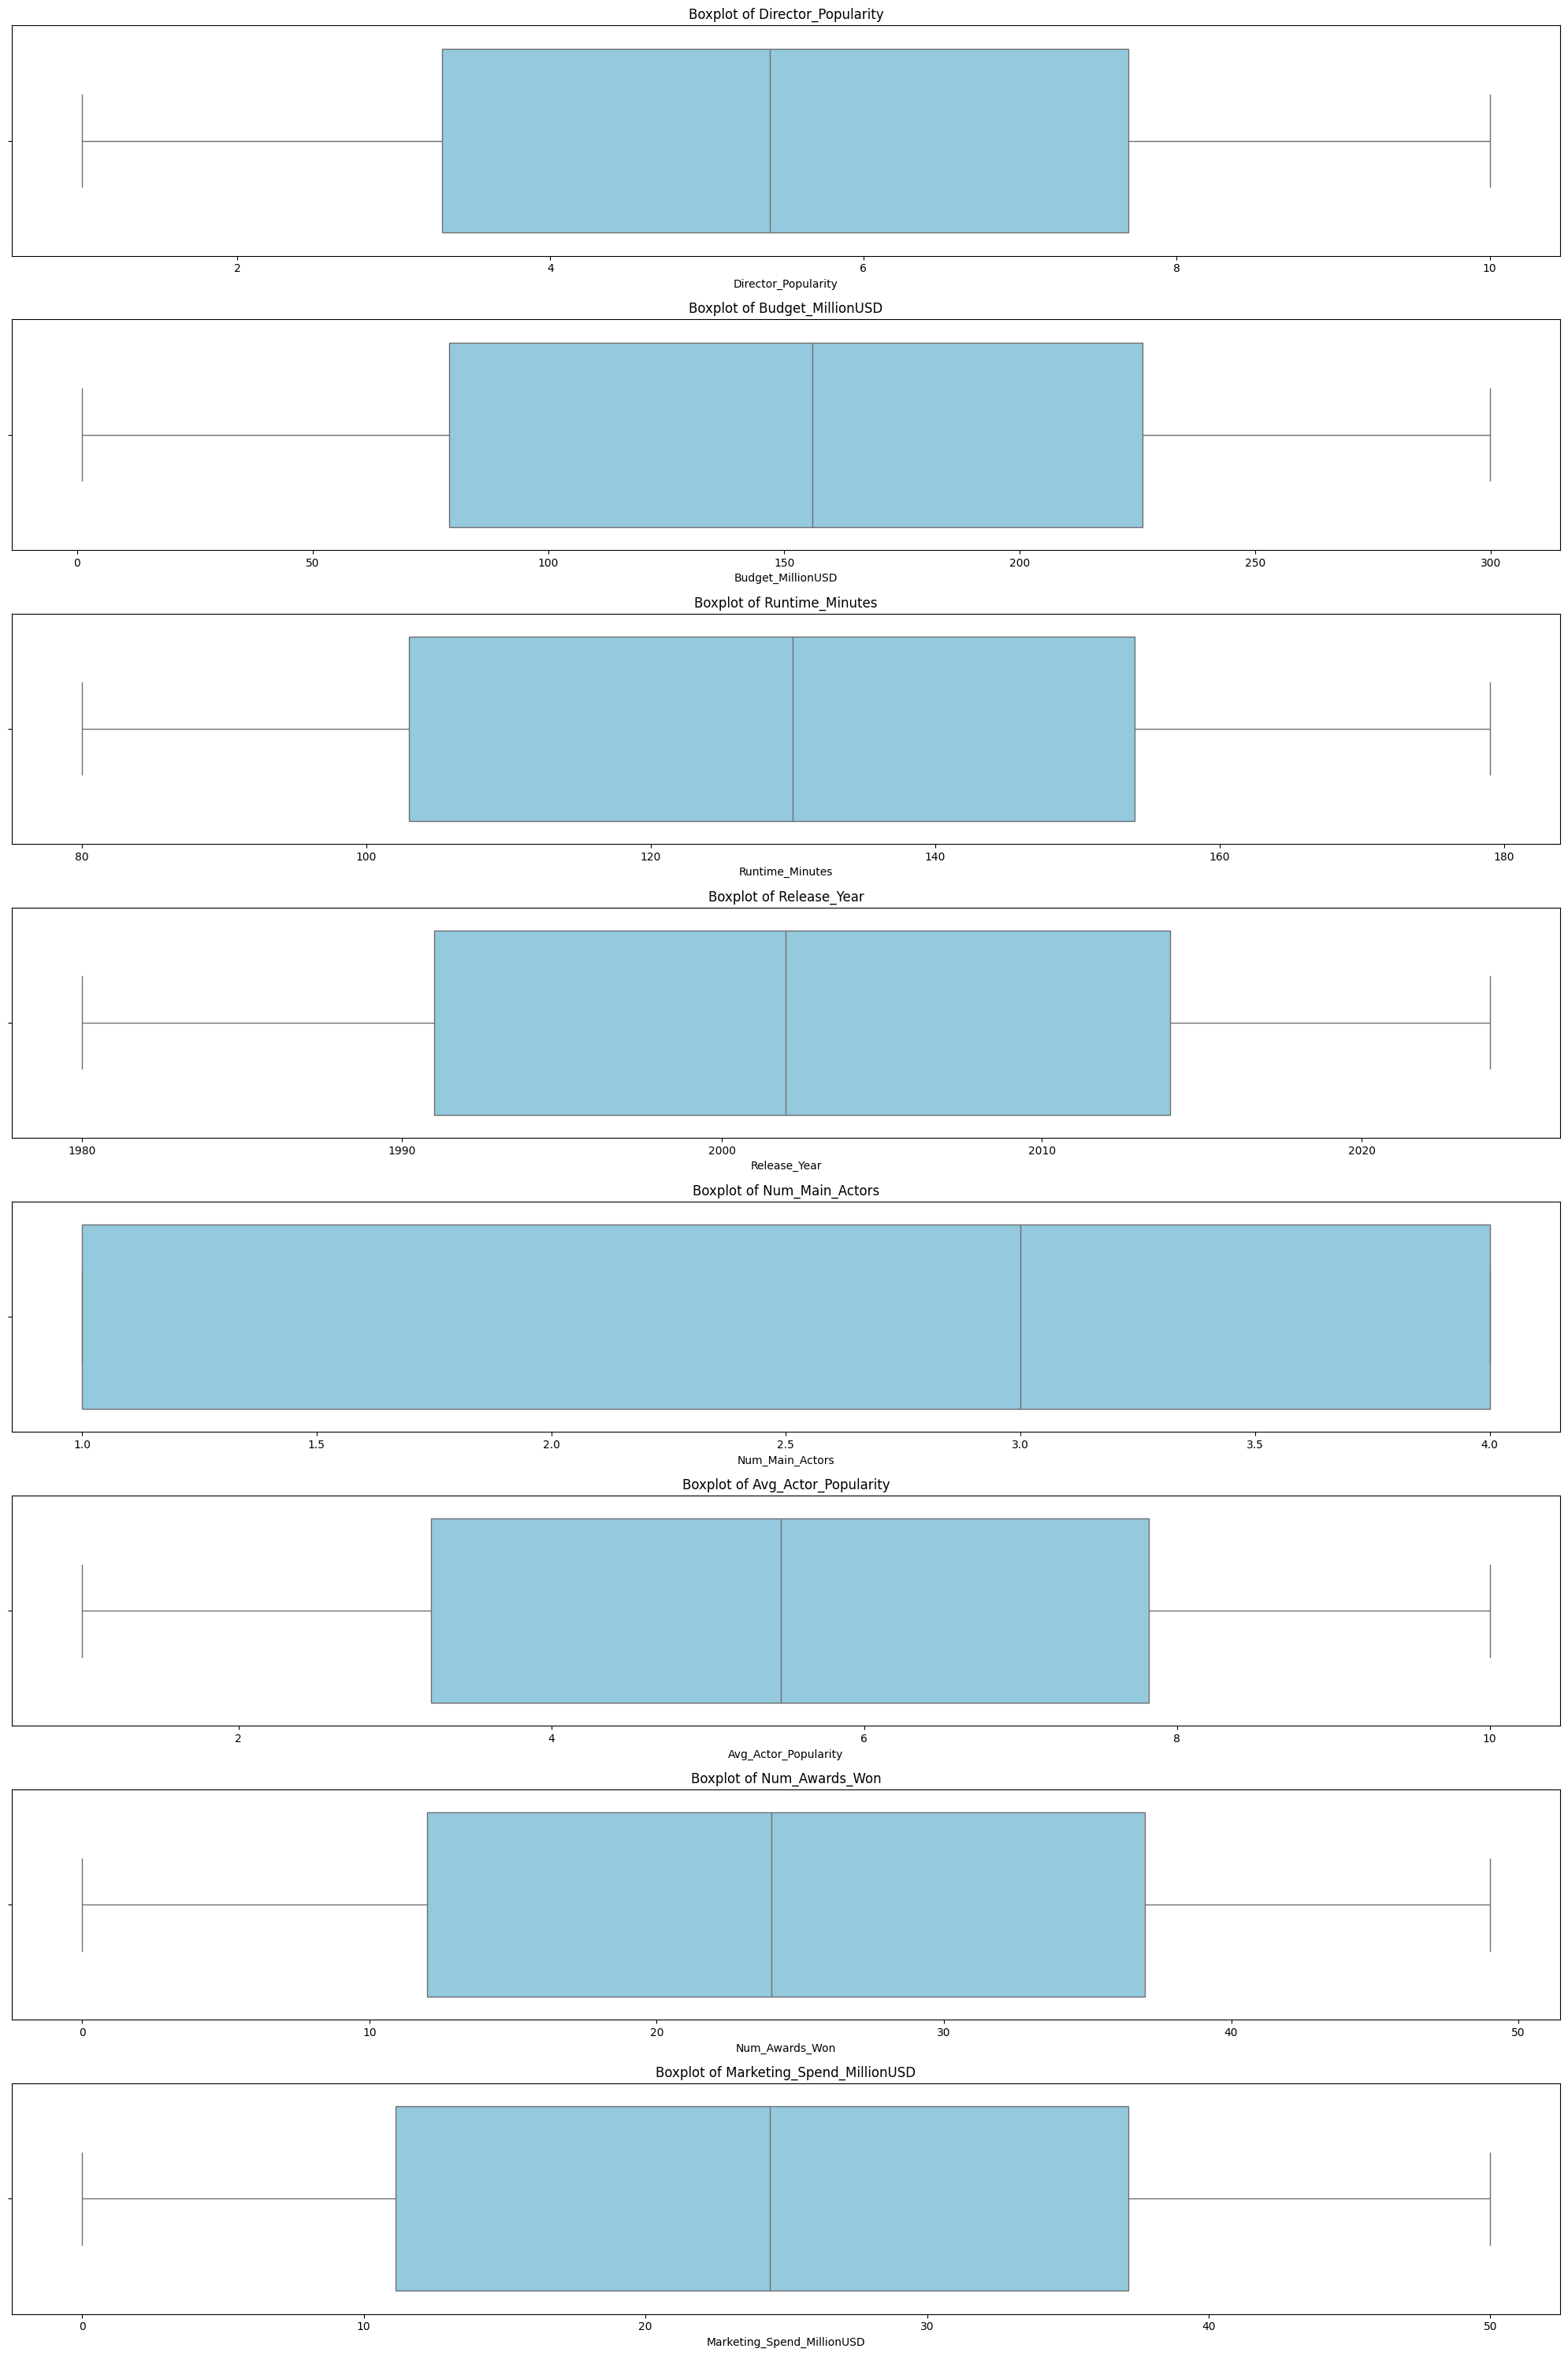

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = movie_rating_dataframe.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x = movie_rating_dataframe[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
categorical_features = []
quantitative_features = []

for col in movie_rating_dataframe.columns:
    if movie_rating_dataframe[col].dtype == 'object':
        categorical_features.append(col)
    elif movie_rating_dataframe[col].dtype in ['int64', 'float64']:
        quantitative_features.append(col)

print(f"Categorical Features: {categorical_features}")
print(f"Quantitative Features: {quantitative_features}")



Categorical Features: ['Genre', 'Has_Famous_Producer', 'Is_Sequel', 'Rating_Category']
Quantitative Features: ['Director_Popularity', 'Budget_MillionUSD', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD']


In [ ]:
movie_rating_dataframe['Genre'].value_counts()

,count
Genre,
Action,188
Horror,188
Comedy,178
Romance,176
Drama,172
Sci-Fi,169


In [ ]:
numerical_data.nunique()

,0
Director_Popularity,626
Budget_MillionUSD,1079
Runtime_Minutes,100
Release_Year,45
Num_Main_Actors,4
Avg_Actor_Popularity,629
Num_Awards_Won,50
Marketing_Spend_MillionUSD,956


In [ ]:
print(movie_rating_dataframe.isna().sum())

Genre                         129
Director_Popularity           133
Budget_MillionUSD             104
Runtime_Minutes               126
Release_Year                  112
Num_Main_Actors               125
Avg_Actor_Popularity          134
Has_Famous_Producer           129
Num_Awards_Won                139
Marketing_Spend_MillionUSD    111
Is_Sequel                     117
Rating_Category                 0
dtype: int64


In [ ]:
unique_counts = categorical_data.nunique()
print(unique_counts)

Genre                  6
Has_Famous_Producer    2
Is_Sequel              2
Rating_Category        4
dtype: int64


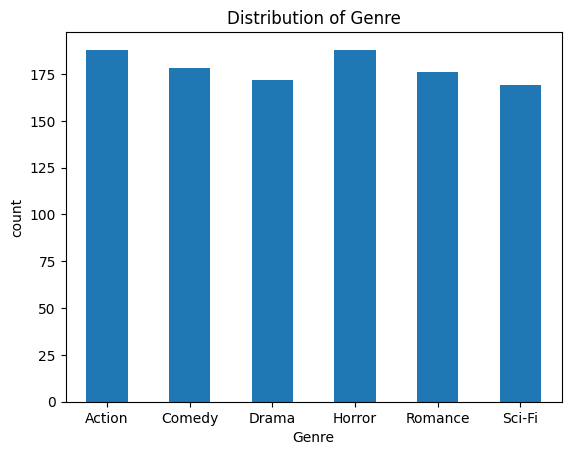

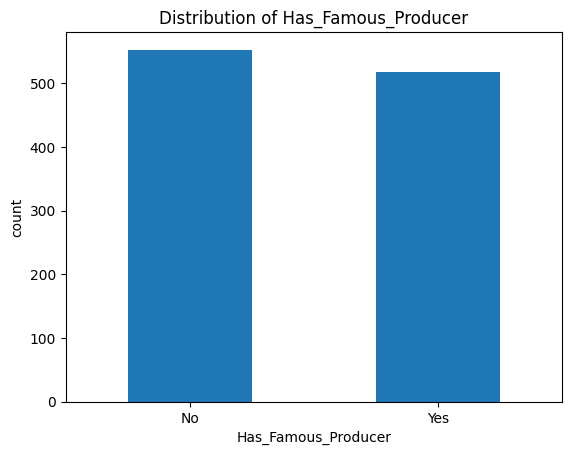

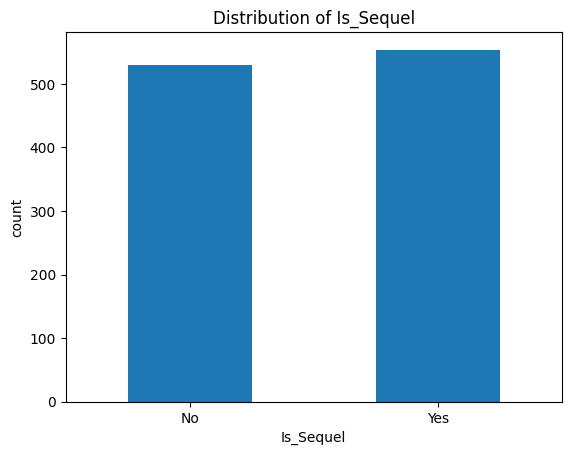

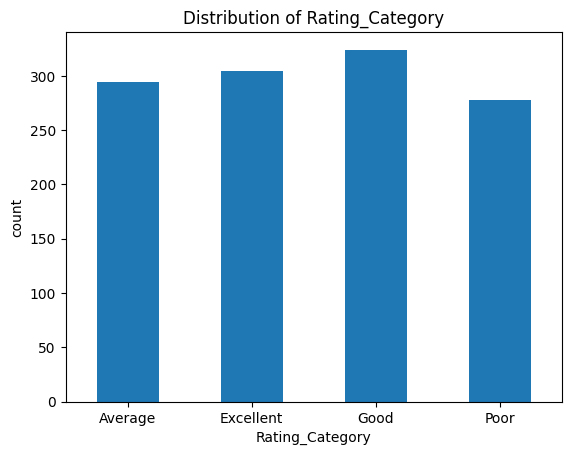

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

In [ ]:
null_value_rows = movie_rating_dataframe.isnull().any(axis=1).sum()
print(null_value_rows)

837


In [ ]:
null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Director_Popularity', 'Budget_MillionUSD', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<Axes: >

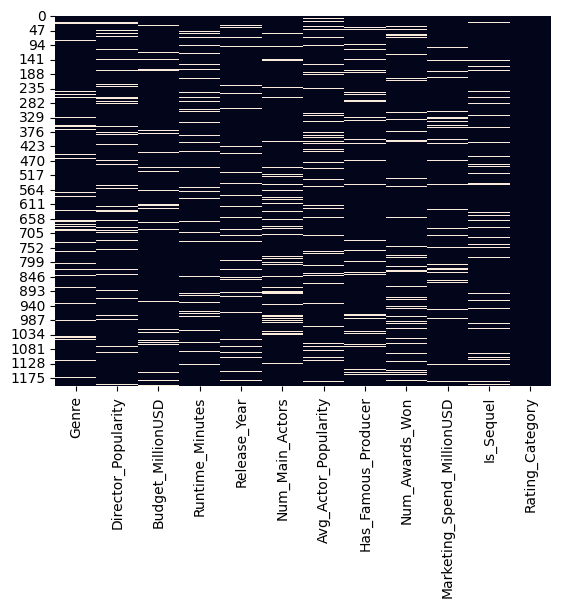

In [ ]:
import seaborn as sns
sns.heatmap(movie_rating_dataframe.isnull(), cbar=False)

In [ ]:
if movie_rating_dataframe['Director_Popularity'].isna().any():
    avg_Director_Popularity = movie_rating_dataframe['Director_Popularity'].mean()
    movie_rating_dataframe['Director_Popularity'].fillna(avg_Director_Popularity, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Budget_MillionUSD', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-26-0211f1d8b05f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Director_Popularity'].fillna(avg_Director_Popularity, inplace=True)


In [ ]:
if movie_rating_dataframe['Budget_MillionUSD'].isna().any():
    avg_Budget_MillionUSD = movie_rating_dataframe['Budget_MillionUSD'].mean()
    movie_rating_dataframe['Budget_MillionUSD'].fillna(avg_Budget_MillionUSD, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Runtime_Minutes', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-27-23dbf34e012d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Budget_MillionUSD'].fillna(avg_Budget_MillionUSD, inplace=True)


In [ ]:
if movie_rating_dataframe['Runtime_Minutes'].isna().any():
    avg_runtime = round(movie_rating_dataframe['Runtime_Minutes'].mean())  # Round to nearest integer
    movie_rating_dataframe['Runtime_Minutes'].fillna(avg_runtime, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)


['Genre', 'Release_Year', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-28-1967677f6775>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Runtime_Minutes'].fillna(avg_runtime, inplace=True)


In [ ]:
if movie_rating_dataframe['Release_Year'].isna().any():
    is_null_value = movie_rating_dataframe['Release_Year'].isna()
    random_years = np.random.randint(1950, 2026, size = is_null_value.sum())
    movie_rating_dataframe.loc[is_null_value, 'Release_Year'] = random_years
null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Num_Main_Actors', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


In [ ]:
is_null_value = movie_rating_dataframe['Num_Main_Actors'].isna()
num_nulls = is_null_value.sum()

movie_rating_dataframe.loc[is_null_value, 'Num_Main_Actors'] = np.random.choice([1, 2, 3, 4, 5], size=num_nulls)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)


['Genre', 'Avg_Actor_Popularity', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


In [ ]:
if movie_rating_dataframe['Avg_Actor_Popularity'].isna().any():
    avg_runtime = round(movie_rating_dataframe['Avg_Actor_Popularity'].mean())
    movie_rating_dataframe['Avg_Actor_Popularity'].fillna(avg_runtime, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-31-eb2a85538a5a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Avg_Actor_Popularity'].fillna(avg_runtime, inplace=True)


In [ ]:
has_famous_producer_col = 'Has_Famous_Producer'

if has_famous_producer_col in movie_rating_dataframe.columns:
    movie_rating_dataframe[has_famous_producer_col] = movie_rating_dataframe[has_famous_producer_col].replace({'Yes': 1, 'No': 0})

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)


['Genre', 'Has_Famous_Producer', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-32-61d9eaddf8b5>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movie_rating_dataframe[has_famous_producer_col] = movie_rating_dataframe[has_famous_producer_col].replace({'Yes': 1, 'No': 0})


In [ ]:
is_null_value = movie_rating_dataframe['Has_Famous_Producer'].isna()
movie_rating_dataframe.loc[is_null_value, 'Has_Famous_Producer'] = np.random.choice([0, 1], size = is_null_value.sum())

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)


['Genre', 'Num_Awards_Won', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


In [ ]:
if movie_rating_dataframe['Num_Awards_Won'].isna().any():
    avg_Num_Awards_Won = round(movie_rating_dataframe['Num_Awards_Won'].mean())
    movie_rating_dataframe['Num_Awards_Won'].fillna(avg_Num_Awards_Won, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Marketing_Spend_MillionUSD', 'Is_Sequel']


<ipython-input-34-f851232f8a89>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Num_Awards_Won'].fillna(avg_Num_Awards_Won, inplace=True)


In [ ]:
if movie_rating_dataframe['Marketing_Spend_MillionUSD'].isna().any():
    avg_Budget_MillionUSD = movie_rating_dataframe['Marketing_Spend_MillionUSD'].mean()
    movie_rating_dataframe['Marketing_Spend_MillionUSD'].fillna(avg_Budget_MillionUSD, inplace=True)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Is_Sequel']


<ipython-input-35-19c8d65a223e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_rating_dataframe['Marketing_Spend_MillionUSD'].fillna(avg_Budget_MillionUSD, inplace=True)


In [ ]:
Is_Sequel = 'Is_Sequel'

if Is_Sequel in movie_rating_dataframe.columns:
    movie_rating_dataframe[Is_Sequel] = movie_rating_dataframe[Is_Sequel].replace({'Yes': 1, 'No': 0})

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre', 'Is_Sequel']


<ipython-input-36-d91ceee9674a>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movie_rating_dataframe[Is_Sequel] = movie_rating_dataframe[Is_Sequel].replace({'Yes': 1, 'No': 0})


In [ ]:
is_null_value = movie_rating_dataframe['Is_Sequel'].isna()
movie_rating_dataframe.loc[is_null_value, 'Is_Sequel'] = np.random.choice([0, 1], size = is_null_value.sum())

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

['Genre']


In [ ]:
import numpy as np

movie_rating_dataframe['Genre'] = movie_rating_dataframe['Genre'].replace({
    'Action': 1,
    'Horror': 2,
    'Comedy': 3,
    'Romance': 4,
    'Drama': 5,
    'Sci-Fi': 6
})


is_null = movie_rating_dataframe['Genre'].isna()
num_nulls = is_null.sum()

movie_rating_dataframe.loc[is_null, 'Genre'] = np.random.choice([1, 2, 3, 4, 5, 6], size=num_nulls)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

[]


<ipython-input-38-d69796c86124>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movie_rating_dataframe['Genre'] = movie_rating_dataframe['Genre'].replace({


In [ ]:
movie_rating_dataframe['Rating_Category'].value_counts()

,count
Rating_Category,
Good,324
Excellent,304
Average,294
Poor,278


In [ ]:
import numpy as np

movie_rating_dataframe['Rating_Category'] = movie_rating_dataframe['Rating_Category'].replace({
    'Good': 1,
    'Excellent': 2,
    'Average': 3,
    'Poor': 4,

})


is_null = movie_rating_dataframe['Rating_Category'].isna()
num_nulls = is_null.sum()

movie_rating_dataframe.loc[is_null, 'Rating_Category'] = np.random.choice([1, 2, 3, 46], size=num_nulls)

null_value_cols = movie_rating_dataframe.columns[movie_rating_dataframe.isna().any()].tolist()
print(null_value_cols)

[]


<ipython-input-40-881e13bd785e>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movie_rating_dataframe['Rating_Category'] = movie_rating_dataframe['Rating_Category'].replace({


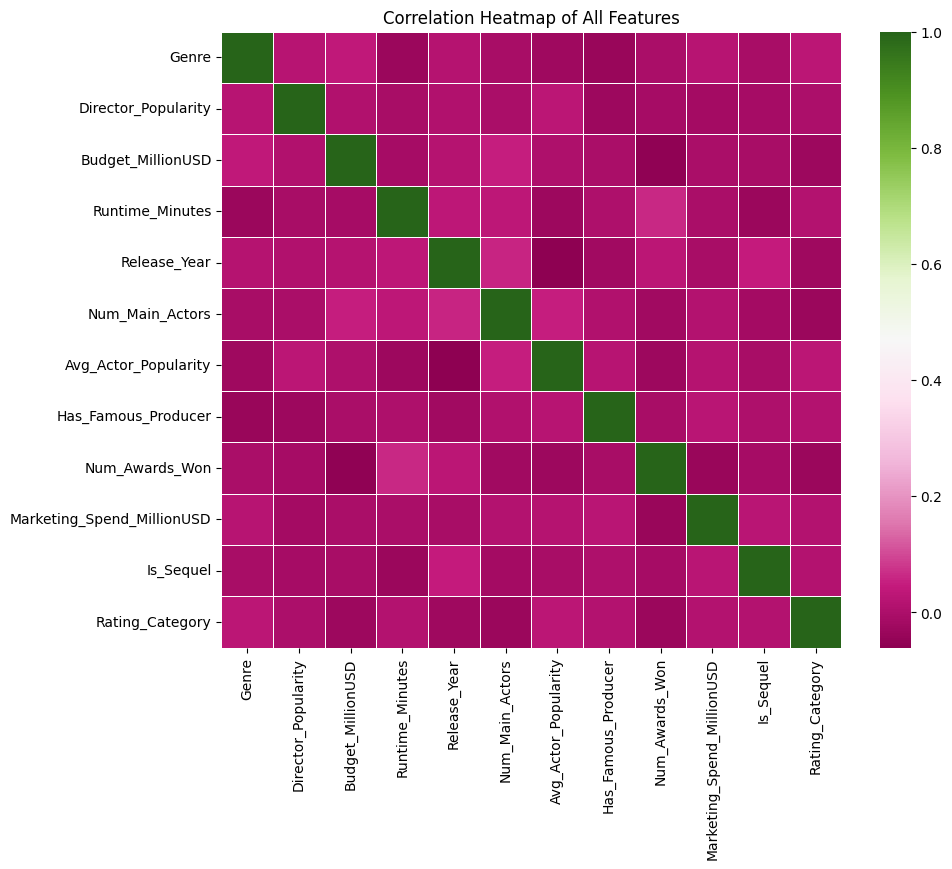

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = movie_rating_dataframe.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='PiYG', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

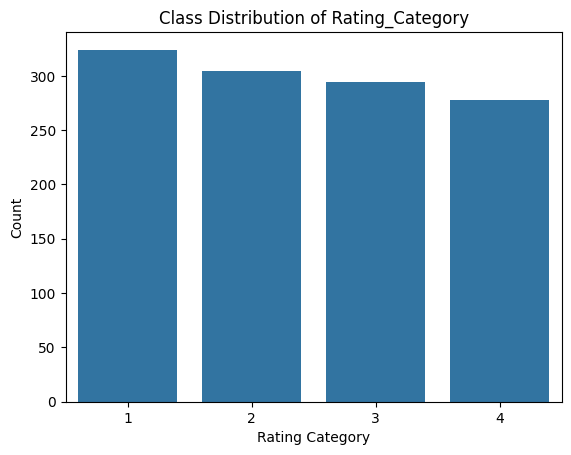

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Rating_Category', data=movie_rating_dataframe)
plt.title('Class Distribution of Rating_Category')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.show()

In [ ]:
print(movie_rating_dataframe['Rating_Category'].unique())

[2 1 3 4]


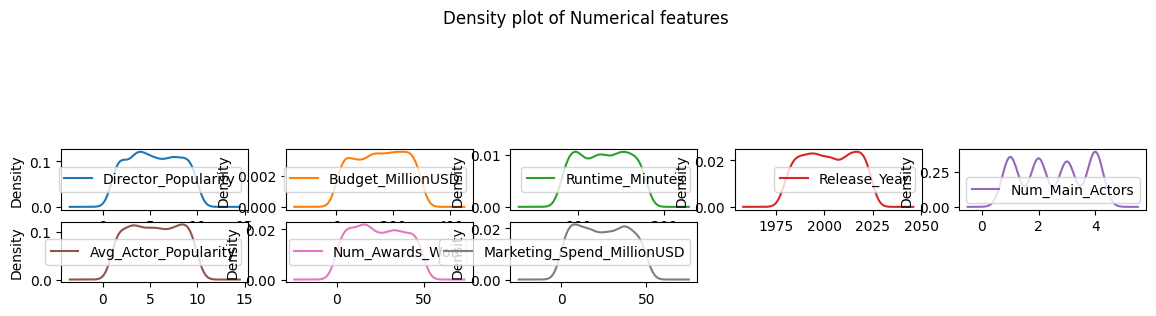

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(15,5),title="Density plot of Numerical features",sharex=False)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

X = movie_rating_dataframe.drop(columns=['Rating_Category'])
y = movie_rating_dataframe['Rating_Category']


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 60)

In [ ]:
import numpy as np

print(np.unique(y_train))


[1 2 3 4]


**Model**


In [ ]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Accuracy: 0.225
Confusion Matrix:
 [[52 28  0  9]
 [62 21  0 10]
 [60 20  0 13]
 [58 16  3  8]]
Classification Report:
               precision    recall  f1-score   support

           1       0.22      0.58      0.32        89
           2       0.25      0.23      0.24        93
           3       0.00      0.00      0.00        93
           4       0.20      0.09      0.13        85

    accuracy                           0.23       360
   macro avg       0.17      0.23      0.17       360
weighted avg       0.17      0.23      0.17       360



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


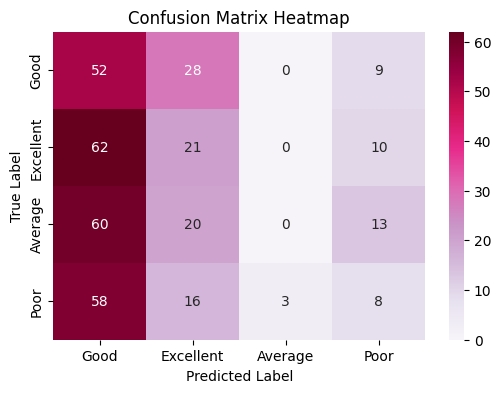

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Good', 'Excellent', 'Average', 'Poor'],
            yticklabels=['Good', 'Excellent', 'Average', 'Poor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [ ]:
y_pred_proba = model.predict_proba(x_test)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Multiclass ROC AUC Score (OvR): {roc_auc:.2f}")

Multiclass ROC AUC Score (OvR): 0.49


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Accuracy: 0.21944444444444444
Confusion Matrix:
 [[22 23 28 16]
 [29 16 23 25]
 [36 11 19 27]
 [27 18 18 22]]
Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.25      0.22        89
           2       0.24      0.17      0.20        93
           3       0.22      0.20      0.21        93
           4       0.24      0.26      0.25        85

    accuracy                           0.22       360
   macro avg       0.22      0.22      0.22       360
weighted avg       0.22      0.22      0.22       360



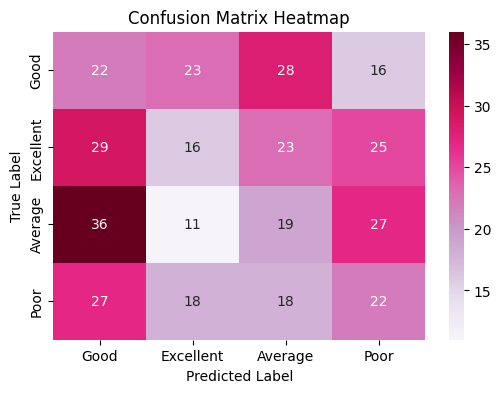

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Good', 'Excellent', 'Average', 'Poor'],
            yticklabels=['Good', 'Excellent', 'Average', 'Poor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
y_pred_proba = model.predict_proba(x_test)
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Multiclass ROC AUC Score (OvR): {roc_auc:.2f}")

Multiclass ROC AUC Score (OvR): 0.48


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', solver='adam',
                      max_iter=300, batch_size=128, random_state=42)

model.fit(x_train, y_train)


y_pred = model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)


print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)


Accuracy: 0.25833333333333336
Confusion Matrix:
 [[ 0  0 89  0]
 [ 0  0 93  0]
 [ 0  0 93  0]
 [ 0  0 85  0]]
Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        89
           2       0.00      0.00      0.00        93
           3       0.26      1.00      0.41        93
           4       0.00      0.00      0.00        85

    accuracy                           0.26       360
   macro avg       0.06      0.25      0.10       360
weighted avg       0.07      0.26      0.11       360



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


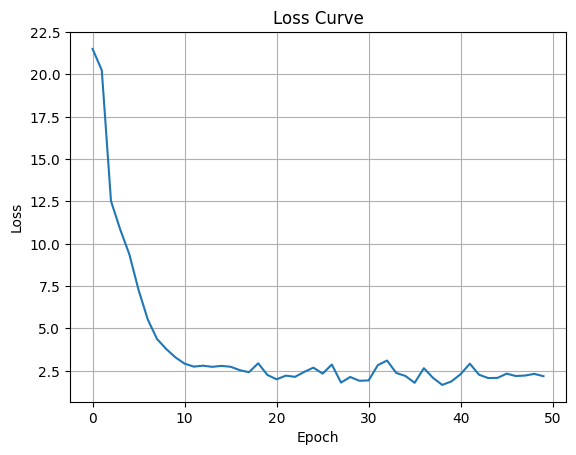

In [ ]:
import matplotlib.pyplot as plt


plt.plot(model.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


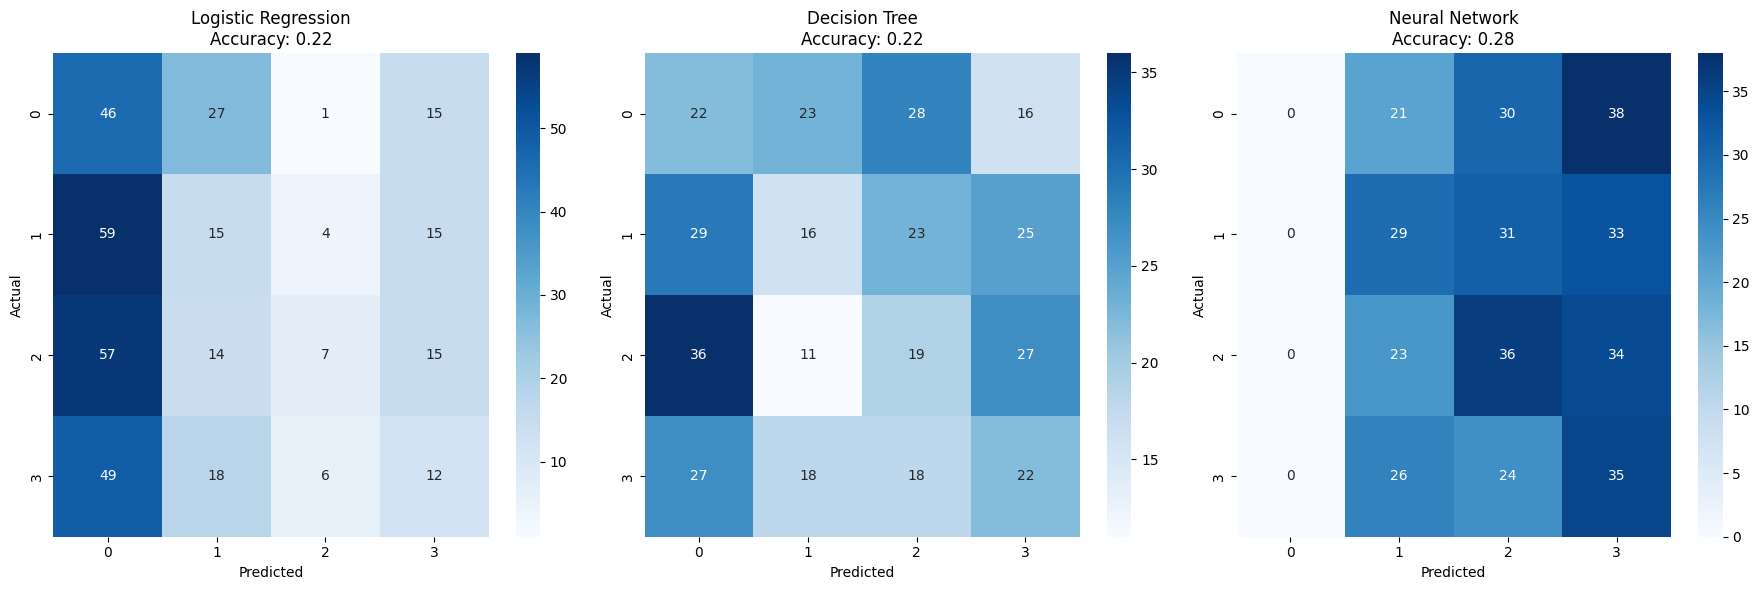

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

plt.figure(figsize=(18, 6))  # 1 row, 3 columns for 3 models

for i, (name, model) in enumerate(models.items(), 1):
    # Fit the model
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name}\nAccuracy: {acc:.2f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()